In [1]:
print("ok")

ok


In [2]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [3]:
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

In [4]:
if not GOOGLE_API_KEY:
    raise ValueError("GOOGLE_API_KEY is missing from .env")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [6]:
chat_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")
# chat_llm = ChatGoogleGenerativeAI(model = "gemini-3-flash-preview")

In [7]:
chat_llm.invoke("Hello, how are you?").content

"Hello! I am doing well, thank you for asking. As a large language model, I don't experience feelings in the same way humans do, but I am functioning optimally and ready to assist you.\n\nHow are you today? I hope you're having a good one!"

In [8]:
from typing_extensions import TypedDict, Annotated
import operator

In [9]:
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [10]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage],operator.add]

In [11]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI response."""
    response = chat_llm.invoke(state["messages"])
    return{
        "messages":[response]
    }

In [12]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_msg = state["messages"][-1]
    text = last_msg.content
    # Handle both string and list content
    if isinstance(text, list):
        text = str(text)
    token_number = len(text.split())
    summary = f"Total tokens in generates answer: {token_number}"
    return{
        "messages":[AIMessage(content=summary)]
    }

In [13]:
from langgraph.graph import StateGraph

In [14]:
builder = StateGraph(GraphState)

In [15]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [16]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call","token_counter")
builder.set_finish_point("token_counter")

In [17]:
app = builder.compile()

In [18]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [19]:
from IPython.display import Image, display

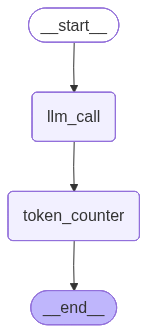

In [20]:
display(Image(app.get_graph().draw_mermaid_png()))

In [21]:
result = app.invoke({
    "messages":[HumanMessage(content="Hi,Tell me what are AI agents.")]
})

In [22]:
result

{'messages': [HumanMessage(content='Hi,Tell me what are AI agents.', additional_kwargs={}, response_metadata={}),
  AIMessage(content='AI agents are essentially **autonomous entities that can perceive their environment, make decisions, and take actions to achieve specific goals.** Think of them as intelligent software programs that can operate independently and adapt to changing circumstances.\n\nHere\'s a breakdown of what makes an AI agent:\n\n**Key Characteristics:**\n\n*   **Perception:** Agents can sense their surroundings. This can be through various means:\n    *   **Sensors:** In the physical world, this could be cameras, microphones, touch sensors, etc.\n    *   **Data Streams:** In the digital world, this could be reading websites, databases, sensor logs, user input, etc.\n*   **Decision-Making/Reasoning:** Based on their perceptions and internal knowledge (which can include rules, learned models, or goals), agents can process information and decide what to do next. This ofte

In [23]:
for m in result["messages"]:
    print(type(m).__name__,":",m.content)

HumanMessage : Hi,Tell me what are AI agents.
AIMessage : AI agents are essentially **autonomous entities that can perceive their environment, make decisions, and take actions to achieve specific goals.** Think of them as intelligent software programs that can operate independently and adapt to changing circumstances.

Here's a breakdown of what makes an AI agent:

**Key Characteristics:**

*   **Perception:** Agents can sense their surroundings. This can be through various means:
    *   **Sensors:** In the physical world, this could be cameras, microphones, touch sensors, etc.
    *   **Data Streams:** In the digital world, this could be reading websites, databases, sensor logs, user input, etc.
*   **Decision-Making/Reasoning:** Based on their perceptions and internal knowledge (which can include rules, learned models, or goals), agents can process information and decide what to do next. This often involves:
    *   **Problem-solving:** Finding solutions to challenges.
    *   **Pla

In [24]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [25]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5, doc_content_chars_max=300)

In [26]:
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [27]:
wiki_tool.run({"query":"What are AI agents?"})

'Page: AI agent\nSummary: In the context of generative artificial intelligence, AI agents (also referred to as compound AI systems or agentic AI) are a class of intelligent agents distinguished by their ability to operate autonomously in complex environments. Agentic AI tools prioritize decision-makin'

'Page: AI agent\nSummary: In the context of generative artificial intelligence, AI agents (also referred to as compound AI systems or agentic AI) are a class of intelligent agents distinguished by their ability to operate autonomously in complex environments. Agentic AI tools prioritize decision-makin'

In [28]:
import os
from langchain_community.tools import TavilySearchResults
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [29]:
print(TAVILY_API_KEY)

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


In [30]:
tavily_tool = TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

C:\Users\Sahil\AppData\Local\Temp\ipykernel_1988\1291469283.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(tavily_api_key=TAVILY_API_KEY)


In [31]:
tavily_tool.invoke({"query":"What is the current AQI index in Delhi"})

[{'title': 'Delhi Air Quality Index (AQI) Today',
  'url': 'https://www.indiatoday.in/weather/delhi-air-quality-index-aqi-today',
  'content': "How is the air quality in your city Delhi today? What is the current Air Quality Index (AQI) in Delhi, and what is the air pollution level like?Get up-to-the-minute  Air Quality Index (AQI) readings for Delhi:-1). Current PM2.5 and PM10 levels stand at 207 and 148 in Pooth Khurd, Bawana. 2). The highest AQI recorded in Delhi is 207 in Pooth Khurd, Bawana, and the lowest AQI is 76 in Mandir Marg.3). Yesterday (26-02-2026), the Air Pollution Index in Delhi was 210.4). Today (27-02-2026), the most polluted area in Delhi is Pooth Khurd, Bawana.5). Today (27-02-2026), the cleanest air pocket in Delhi is Mandir Marg. Our real-time AQI tracker enables you to view day-to-day pollution fluctuations, pinpoint high-smog windows, and plan safer outdoor routines with confidence. Stay updated with [...] safer outdoor routines with confidence. Stay updated wi

In [32]:
from langchain_community.tools import DuckDuckGoSearchRun
search = DuckDuckGoSearchRun()

In [33]:
search.invoke("What is current temperature in Manali?")

Impersonate 'safari_18.2' does not exist, using 'random'


'2 days ago · Manali weather today shows a temperature of -10.1°C with Clear conditions. The current weather in Manali feels like -17.5°C, with humidity at 71%, wind blowing at 17.6 km/h, and a UV Index of 0. Get Manali , HP, IN current weather report with temperature , feels like, wind, humidity, pressure, UV and more from TheWeatherNetwork.com. 6 hours ago · Current Manali weather condition is Clear with real-time temperature (-12°C), humidity 69%, wind 16.9km/h, pressure (1023mb), UV (0), visibility (10km) in Himachal Pradesh. Today’s and tonight’s Manali , Himachal Pradesh, India weather forecast, weather conditions and Doppler radar from The Weather Channel and weather .com Feb 18, 2026 · Today’s Weather in Manali : In Manali today, the weather is expected to be Clear with a maximum temperature of 2.2°C and a minimum of -9.8°C.'

In [34]:
from langchain_community.tools import YouTubeSearchTool
tool = YouTubeSearchTool()

In [35]:
print(tool.name)
print(tool.description)

youtube_search
search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional


In [36]:
tool.run("Mr Beast")

"['https://www.youtube.com/watch?v=5OLs1GWB4OA&pp=ygUITXIgQmVhc3Q%3D', 'https://www.youtube.com/watch?v=pzBi1nwDn8U&pp=ygUITXIgQmVhc3Q%3D']"

In [37]:
from langchain.tools import tool

In [38]:
@tool
def divide(a:int,b:int) -> int:
    """Divide the two numbers"""
    try:
        return a/b
    except Exception as e:
        return "Denominator should not be zero"

In [39]:
print(divide.invoke({"a":15,"b":20}))
print(divide.invoke({"a":15,"b":0}))

0.75
Denominator should not be zero


In [40]:
print(divide.name)
print(divide.description)
print(divide.args)

divide
Divide the two numbers
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [41]:
@tool
def get_length(a:str) -> int:
    """Get the length of the string"""
    try:
        length = len(a)
        return length
    except Exception as e:
        return f"Error: {e}"

In [42]:
get_length.invoke("ChristianoRonaldo")

17

In [43]:
import yfinance as yf

In [44]:
from pandas import Period


@tool
def get_stock_price(ticker:str) ->str:
    """this is the tool to get stock price using yfinance"""
    try:
        stock = yf.Ticker(ticker)

        #Get the last 1day historical data
        data = stock.history(period = "1d")

        if data.empty:
            return f"No data found "
        
        latest_close = data["Close"].iloc[-1]

        #Detect Currency
        currency = stock.info.get("currency", "")
        symbol_map = {
             "USD":"$",
             "EUR":"€",
             "INR":"₹",
        }

        symbol = symbol_map.get(currency, "")
        currency_text = currency if currency else ""

        if symbol:
             return f"Last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
              return f"Last closing price of {ticker.upper()} was {latest_close:.2f}{currency_text}."
        
    except Exception as e:
            return f"Error: {str(e)}"    

In [45]:
get_stock_price.invoke("TCS.NS")

'Last closing price of TCS.NS was ₹2641.30.'

In [46]:
get_stock_price.invoke("AAPL")

'Last closing price of AAPL was $272.95.'

In [47]:
tools = [get_length,get_stock_price,divide,tavily_tool]

In [48]:
llm_with_tools = chat_llm.bind_tools(tools)

In [49]:
result = llm_with_tools.invoke("Divide 50 by 5")

In [50]:
result #LLM will not generate response because its calling the tool, rather than doing calculation on its own which will significantly reduce tokens 

AIMessage(content='', additional_kwargs={'function_call': {'name': 'divide', 'arguments': '{"a": 50, "b": 5}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c9ddb-8cd4-7b43-b60c-e61279e9ca16-0', tool_calls=[{'name': 'divide', 'args': {'a': 50, 'b': 5}, 'id': '098453d2-a420-451d-90a4-7b23a359a9e3', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 209, 'output_tokens': 19, 'total_tokens': 228, 'input_token_details': {'cache_read': 0}})

In [51]:
result.tool_calls

[{'name': 'divide',
  'args': {'a': 50, 'b': 5},
  'id': '098453d2-a420-451d-90a4-7b23a359a9e3',
  'type': 'tool_call'}]

In [52]:
#without tool
result = llm_with_tools.invoke("Which is the biggest part of our brain")

In [53]:
result.content

''

'I am sorry, I cannot answer this question. The available tools do not have the ability to provide information about the human brain.'

In [54]:
#After adding travily_tool
result = llm_with_tools.invoke("Which is the biggest part of our brain")

In [55]:
result.content

''

In [56]:
result.tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'biggest part of the human brain'},
  'id': 'ffd352bf-c619-4265-96e9-ed9cd8989f0b',
  'type': 'tool_call'}]

In [57]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState, StateGraph, END, START
from langgraph.prebuilt import ToolNode, tools_condition

In [72]:
SYSTEM_PROMPT = SystemMessage("You are a helpful assistant that can use tools to answer questions.")

In [ ]:
def function_1(state: MessagesState):
    user_question = state["messages"]
    input_question = [SYSTEM_PROMPT]+user_question
    response = llm_with_tools.invoke(input_question)

    return{
        "messages":[response]
    }

In [59]:
tools

[StructuredTool(name='get_length', description='Get the length of the string', args_schema=<class 'langchain_core.utils.pydantic.get_length'>, func=<function get_length at 0x0000027597374860>),
 StructuredTool(name='get_stock_price', description='this is the tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x00000275C2608FE0>),
 StructuredTool(name='divide', description='Divide the two numbers', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x0000027597C26FC0>),
 TavilySearchResults(api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********')))]

In [60]:
function_2 = ToolNode(tools)

In [61]:
workflow = StateGraph(MessagesState)

In [62]:
workflow.add_node("llm", function_1)

In [63]:
workflow.add_node("tools", function_2)

In [64]:
workflow.add_edge(START, "llm")

In [65]:
workflow.add_conditional_edges(
    "llm",
    tools_condition
)

In [66]:
workflow.add_edge("tools","llm")

In [67]:
app = workflow.compile()

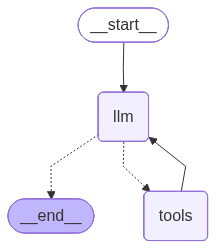

In [68]:
from IPython.display import Image,display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [70]:
result = app.invoke({
    "messages": [HumanMessage(content="What is the stock price of TSLA?")]
})

In [71]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the stock price of TSLA?
